# Stage 6 — Resilient Hyperparameter Tuning, Threshold Selection & Calibration

**Project:** Heart_Attack_Risk_Assessment  
**Team:** team05 | **Student:** s502  
**Course:** ITI113 | **Semester:** 26S1  
**Environment:** AWS SageMaker Studio + SageMaker-hosted MLflow

This version is designed to survive SageMaker disconnections and make slow models easier to diagnose.

### Improvements
- Logistic Regression, XGBoost and Random Forest run in separate cells.
- Every completed model is immediately saved under `artifacts/stage6/`.
- Best estimators are saved with `joblib`.
- Best parameters and tuning summaries are saved as JSON/CSV.
- A recovery cell reloads completed models after a kernel restart.
- OOF predictions are generated and saved one model at a time.
- Random Forest uses the lighter 15-fit search by default.
- The locked 20% holdout remains untouched.

## 1. Install / verify dependencies

In [4]:
%pip install -q -U mlflow sagemaker-mlflow scikit-learn xgboost joblib
print("Packages ready.")

Note: you may need to restart the kernel to use updated packages.
Packages ready.


## 2. Robust project-root detection

In [5]:
from pathlib import Path
import json
import warnings
import time

import boto3
import joblib
import numpy as np
import pandas as pd

EXPECTED_PROJECT_FOLDER = "Heart_Attack_Risk_Assessment"

current_path = Path.cwd().resolve()

if current_path.name == EXPECTED_PROJECT_FOLDER:
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = next(
        (p for p in current_path.parents if p.name == EXPECTED_PROJECT_FOLDER),
        None
    )

if PROJECT_ROOT is None:
    candidate = Path("/home/sagemaker-user/Heart_Attack_Risk_Assessment")
    if candidate.exists():
        PROJECT_ROOT = candidate
    else:
        raise FileNotFoundError(
            f"Could not locate '{EXPECTED_PROJECT_FOLDER}'. "
            f"Current directory: {current_path}"
        )

DATA_DIR = PROJECT_ROOT / "data"
CONFIG_DIR = PROJECT_ROOT / "config"
SRC_DIR = PROJECT_ROOT / "src"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
STAGE6_DIR = ARTIFACT_DIR / "stage6"
MODEL_DIR = STAGE6_DIR / "models"
OOF_DIR = STAGE6_DIR / "oof"
TUNING_DIR = STAGE6_DIR / "tuning"

for d in [ARTIFACT_DIR, STAGE6_DIR, MODEL_DIR, OOF_DIR, TUNING_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MLFLOW_CONFIG_FILE = PROJECT_ROOT / "mlflow_app_config_team05_s502.json"
FEATURE_METADATA_FILE = CONFIG_DIR / "feature_metadata.json"
STAGE5_COMPARISON_FILE = CONFIG_DIR / "stage5_model_comparison.csv"
FULL_TRAIN_FILE = DATA_DIR / "full_train_raw.csv"

print("Current directory :", current_path)
print("Project root      :", PROJECT_ROOT)
print("Stage 6 artifacts :", STAGE6_DIR)

Current directory : /home/sagemaker-user/Heart_Attack_Risk_Assessment
Project root      : /home/sagemaker-user/Heart_Attack_Risk_Assessment
Stage 6 artifacts : /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6


## 3. Validate required Stage 6 files

In [6]:
required = {
    "MLflow config": MLFLOW_CONFIG_FILE,
    "Feature metadata": FEATURE_METADATA_FILE,
    "Stage 5 comparison": STAGE5_COMPARISON_FILE,
    "Full training data": FULL_TRAIN_FILE,
}

missing = []

for label, path in required.items():
    status = "FOUND" if path.exists() else "MISSING"
    try:
        display_path = path.relative_to(PROJECT_ROOT)
    except ValueError:
        display_path = path

    print(f"{status:7} | {label:25} | {display_path}")

    if not path.exists():
        missing.append(str(path))

if missing:
    raise FileNotFoundError(
        "Stage 6 cannot start because required files are missing:\n"
        + "\n".join(missing)
    )

print("\n[OK] All Stage 6 inputs are ready.")

FOUND   | MLflow config             | mlflow_app_config_team05_s502.json
FOUND   | Feature metadata          | config/feature_metadata.json
FOUND   | Stage 5 comparison        | config/stage5_model_comparison.csv
FOUND   | Full training data        | data/full_train_raw.csv

[OK] All Stage 6 inputs are ready.


## 4. Load MLflow configuration

In [7]:
with open(MLFLOW_CONFIG_FILE, "r", encoding="utf-8") as f:
    mlflow_config = json.load(f)

REGION = mlflow_config["REGION"]
MLFLOW_APP_ARN = mlflow_config["MLFLOW_APP_ARN"]
MLFLOW_EXPERIMENT = mlflow_config["EXPERIMENT_NAME"]
TEAM_ID = mlflow_config["TEAM_ID"]
STUDENT_ID = mlflow_config["STUDENT_ID"]
PROJECT_NAME = mlflow_config["PROJECT_NAME"]

COURSE = "ITI113"
SEMESTER = "26S1"
TARGET = "HadHeartAttack"
RANDOM_STATE = 42
CV_FOLDS = 5
RECALL_TARGET = 0.80

assert TEAM_ID == "team05"
assert STUDENT_ID == "s502"

print("Region            :", REGION)
print("MLflow App ARN    :", MLFLOW_APP_ARN)
print("MLflow Experiment :", MLFLOW_EXPERIMENT)
print("Team              :", TEAM_ID)
print("Student           :", STUDENT_ID)
print("Project           :", PROJECT_NAME)

Region            : ap-southeast-1
MLflow App ARN    : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ZOP45XZVBR5D
MLflow Experiment : ITI113/team05/Experiment1
Team              : team05
Student           : s502
Project           : Heart_Attack_Risk_Assessment


## 5. Validate Team05 MLflow App and connect

In [8]:
import mlflow

boto_session = boto3.Session(region_name=REGION)
sm_client = boto_session.client("sagemaker")
sts = boto_session.client("sts")

identity = sts.get_caller_identity()
print("AWS Account :", identity["Account"])
print("Caller ARN  :", identity["Arn"])

tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
mlflow_app_tags = {
    tag["Key"]: tag["Value"]
    for tag in tag_response.get("Tags", [])
}

print("\nMLflow App tags:")
for key, value in mlflow_app_tags.items():
    print(f"  {key}: {value}")

app_team_id = mlflow_app_tags.get("TeamId")

if app_team_id != TEAM_ID:
    raise PermissionError(
        f"MLflow App TeamId={app_team_id}, "
        f"but notebook TEAM_ID={TEAM_ID}."
    )

print(f"\n[OK] TeamId={app_team_id} validated.")

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", MLFLOW_EXPERIMENT)

AWS Account : 044528205969
Caller ARN  : arn:aws:sts::044528205969:assumed-role/SageMakerExecutionRole-ITI113-Team05/SageMaker

MLflow App tags:
  sagemaker:user-profile-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:user-profile/d-zjad5kjaiedi/team05-s501
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-zjad5kjaiedi
  ProjectName: Heart_Attack_Risk_Assessment
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-zjad5kjaiedi/project-space-team05
  Course: ITI113
  TeamId: team05
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s502

[OK] TeamId=team05 validated.


Tracking URI : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ZOP45XZVBR5D
Experiment   : ITI113/team05/Experiment1


## 6. Load Stage 5 evidence and training data

In [9]:
with open(FEATURE_METADATA_FILE, "r", encoding="utf-8") as f:
    FEATURE_METADATA = json.load(f)

stage5 = pd.read_csv(STAGE5_COMPARISON_FILE)
full_train = pd.read_csv(FULL_TRAIN_FILE)

FULL_FEATURES = FEATURE_METADATA["full"]["features"]
FULL_NUMERIC = FEATURE_METADATA["full"]["numeric_features"]
FULL_CATEGORICAL = FEATURE_METADATA["full"]["categorical_features"]

X = full_train[FULL_FEATURES].copy()
y = full_train[TARGET].astype(int).copy()

print("Training shape      :", full_train.shape)
print("Positive prevalence :", f"{y.mean():.4%}")
print("Full feature count  :", len(FULL_FEATURES))

print("\nStage 5 comparison:")
display(stage5.round(4))

Training shape      : (353653, 40)
Positive prevalence : 5.6796%
Full feature count  : 39

Stage 5 comparison:


,model,feature_set,recall,precision,f1,pr_auc,roc_auc,brier_score,fn,fp,run_id
0,xgboost,restricted,0.7866,0.1489,0.2504,0.2361,0.8330,0.1697,4287,90322,7c8812948c4e48279d15383bb5a8479a
1,xgboost,full,0.7773,0.2113,0.3322,0.4138,0.8870,0.1285,4473,58294,a1e4d65e58c14fe6b24fac28fccecf77
2,logistic_regression,restricted,0.7756,0.1512,0.2530,0.2336,0.8309,0.1731,4508,87475,6abd5736134f489094792e2402470028
3,logistic_regression,full,0.7665,0.2159,0.3369,0.4008,0.8847,0.1305,4690,55921,1a2861f5d99e4408b0dee8c59caa483e
4,random_forest,full,0.6349,0.3062,0.4131,0.3853,0.8809,0.0927,7334,28896,fef90ccc5da34bd4b64d3f870c69b6e3
5,random_forest,restricted,0.6058,0.1806,0.2783,0.2139,0.8223,0.1247,7917,55205,3e82b69f303d4196a924c392c26a7989


## 7. Imports, CV and preprocessing

In [10]:
from scipy.stats import loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

CV = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

def build_preprocessor(model_name):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]

    if model_name == "logistic_regression":
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), FULL_NUMERIC),
        ("cat", categorical_pipeline, FULL_CATEGORICAL)
    ])

def build_pipeline(model_name):
    if model_name == "logistic_regression":
        estimator = LogisticRegression(
            max_iter=1500,
            random_state=RANDOM_STATE
        )
    elif model_name == "random_forest":
        estimator = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif model_name == "xgboost":
        estimator = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,

            # Limit CPU/RAM usage
            n_jobs=2,

            # More memory-efficient tree building
            tree_method="hist"
        )
    else:
        raise ValueError(model_name)

    return Pipeline([
        ("preprocessor", build_preprocessor(model_name)),
        ("model", estimator)
    ])

## 8. Bounded search spaces — lighter Random Forest

In [11]:
negative_count = int((y == 0).sum())
positive_count = int((y == 1).sum())
BASE_SCALE_POS_WEIGHT = negative_count / positive_count

SEARCH_SPACES = {
    "logistic_regression": {
        "model__C": loguniform(0.05, 10.0),
        "model__class_weight": [
            "balanced",
            {0: 1.0, 1: 8.0},
            {0: 1.0, 1: 12.0},
            {0: 1.0, 1: 16.0},
        ],
    },

    "xgboost": {
        "model__n_estimators": [150, 200, 250, 300],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.75, 0.85, 0.95, 1.0],
        "model__colsample_bytree": [0.70, 0.80, 0.90, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
        "model__scale_pos_weight": [
            BASE_SCALE_POS_WEIGHT * 0.75,
            BASE_SCALE_POS_WEIGHT,
            BASE_SCALE_POS_WEIGHT * 1.25,
        ],
    },

    "random_forest": {
        "model__n_estimators": [50, 75, 100],
        "model__max_depth": [10, 14],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [2, 4],
        "model__max_features": ["sqrt"],
        "model__class_weight": [
            "balanced",
            "balanced_subsample",
        ],
    }
}

SEARCH_ITERATIONS = {
    "logistic_regression": 6,
    "xgboost": 5,
    "random_forest": 3,
}

print("Search iterations:", SEARCH_ITERATIONS)
print("LR fits :", SEARCH_ITERATIONS["logistic_regression"] * CV_FOLDS)
print("XGB fits:", SEARCH_ITERATIONS["xgboost"] * CV_FOLDS)
print("RF fits :", SEARCH_ITERATIONS["random_forest"] * CV_FOLDS)

Search iterations: {'logistic_regression': 6, 'xgboost': 5, 'random_forest': 3}
LR fits : 30
XGB fits: 25
RF fits : 15


## 9. Persistence helpers

In [12]:
COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "dataset": "CDC BRFSS 2022",
    "target": TARGET,
    "feature_set": "full",
    "stage": "stage6_tuning",
}

def model_artifact_paths(model_name):
    return {
        "model": MODEL_DIR / f"{model_name}_best_estimator.joblib",
        "params": TUNING_DIR / f"{model_name}_best_params.json",
        "summary": TUNING_DIR / f"{model_name}_summary.json",
        "results": TUNING_DIR / f"{model_name}_tuning_results.csv",
        "oof": OOF_DIR / f"{model_name}_oof_predictions.csv",
    }

def save_tuning_result(model_name, search, tuning_table, run_id, elapsed_seconds):
    paths = model_artifact_paths(model_name)

    joblib.dump(search.best_estimator_, paths["model"])

    paths["params"].write_text(
        json.dumps(search.best_params_, indent=2, default=str),
        encoding="utf-8"
    )

    tuning_table.to_csv(paths["results"], index=False)

    summary = {
        "model": model_name,
        "feature_set": "full",
        "best_pr_auc": float(search.best_score_),
        "best_params": search.best_params_,
        "best_index": int(search.best_index_),
        "mlflow_run_id": run_id,
        "elapsed_seconds": float(elapsed_seconds),
        "saved_model": str(paths["model"]),
        "saved_tuning_results": str(paths["results"]),
    }

    paths["summary"].write_text(
        json.dumps(summary, indent=2, default=str),
        encoding="utf-8"
    )

    return summary

def load_saved_tuning_result(model_name):
    paths = model_artifact_paths(model_name)

    if not (paths["model"].exists() and paths["summary"].exists()):
        return None

    estimator = joblib.load(paths["model"])
    summary = json.loads(paths["summary"].read_text(encoding="utf-8"))

    return {
        "model": model_name,
        "best_estimator": estimator,
        "best_params": summary["best_params"],
        "best_pr_auc": summary["best_pr_auc"],
        "run_id": summary.get("mlflow_run_id"),
        "summary": summary,
    }

## 10. Resilient tuning function

In [13]:
def run_tuning(model_name):
    print("\n" + "=" * 100)
    print("TUNING:", model_name)
    print("=" * 100)

    pipeline = build_pipeline(model_name)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=SEARCH_SPACES[model_name],
        n_iter=SEARCH_ITERATIONS[model_name],
        scoring={
            "pr_auc": "average_precision",
            "recall": "recall",
            "precision": "precision",
            "f1": "f1",
            "roc_auc": "roc_auc",
        },
        refit="pr_auc",
        cv=CV,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=2,
        return_train_score=False,
    )

    start = time.time()
    search.fit(X, y)
    elapsed = time.time() - start

    cv_results = pd.DataFrame(search.cv_results_)

    keep_cols = [
        "rank_test_pr_auc",
        "mean_test_pr_auc",
        "std_test_pr_auc",
        "mean_test_recall",
        "std_test_recall",
        "mean_test_precision",
        "mean_test_f1",
        "mean_test_roc_auc",
        "params",
    ]

    tuning_table = (
        cv_results[keep_cols]
        .sort_values("rank_test_pr_auc")
        .reset_index(drop=True)
    )

    print("\nBest PR-AUC:")
    print(search.best_score_)

    print("\nBest parameters:")
    print(json.dumps(search.best_params_, indent=2, default=str))

    run_name = (
        f"{TEAM_ID}_{STUDENT_ID}_{model_name}_full_stage6_tuning"
    )

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tags({
            **COMMON_TAGS,
            "model": model_name,
            "run_type": "bounded_randomized_search",
        })

        mlflow.log_params({
            "model": model_name,
            "feature_set": "full",
            "cv_folds": CV_FOLDS,
            "n_iter": SEARCH_ITERATIONS[model_name],
            "refit_metric": "pr_auc",
            "train_rows": len(X),
            "positive_rate": float(y.mean()),
            "elapsed_seconds": float(elapsed),
        })

        for k, v in search.best_params_.items():
            mlflow.log_param(k.replace("model__", ""), str(v))

        idx = search.best_index_

        mlflow.log_metrics({
            "tuning_best_pr_auc":
                float(cv_results.loc[idx, "mean_test_pr_auc"]),
            "tuning_best_recall_at_0_5":
                float(cv_results.loc[idx, "mean_test_recall"]),
            "tuning_best_precision_at_0_5":
                float(cv_results.loc[idx, "mean_test_precision"]),
            "tuning_best_f1_at_0_5":
                float(cv_results.loc[idx, "mean_test_f1"]),
            "tuning_best_roc_auc":
                float(cv_results.loc[idx, "mean_test_roc_auc"]),
        })

        run_id = run.info.run_id

    summary = save_tuning_result(
        model_name=model_name,
        search=search,
        tuning_table=tuning_table,
        run_id=run_id,
        elapsed_seconds=elapsed
    )

    print("\n" + "=" * 100)
    print(model_name.upper(), "TUNING COMPLETED")
    print("=" * 100)
    print("Best PR-AUC :", summary["best_pr_auc"])
    print("Model saved :", summary["saved_model"])
    print("MLflow Run  :", run_id)
    print("Elapsed mins:", round(elapsed / 60, 2))

    return {
        "model": model_name,
        "search": search,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_pr_auc": float(search.best_score_),
        "run_id": run_id,
        "tuning_table": tuning_table,
    }

## 11. Recovery cell — run after any kernel restart

In [14]:
tuning_results = {}

for model_name in [
    "logistic_regression",
    "xgboost",
    "random_forest",
]:
    recovered = load_saved_tuning_result(model_name)

    if recovered is not None:
        tuning_results[model_name] = recovered
        print(
            f"RECOVERED | {model_name:20} | "
            f"PR-AUC={recovered['best_pr_auc']:.6f}"
        )
    else:
        print(f"NOT FOUND | {model_name}")

print("\nModels currently available:")
print(tuning_results.keys())

RECOVERED | logistic_regression  | PR-AUC=0.401847
RECOVERED | xgboost              | PR-AUC=0.413627
RECOVERED | random_forest        | PR-AUC=0.394735

Models currently available:
dict_keys(['logistic_regression', 'xgboost', 'random_forest'])


## 12. Tune Logistic Regression — separate run

## 13. Tune XGBoost — separate run

In [18]:
if "xgboost" in tuning_results:
    print("XGBoost already recovered. Skipping retraining.")
else:
    tuning_results["xgboost"] = run_tuning(
        "xgboost"
    )

print("\nModels available:")
print(tuning_results.keys())


TUNING: xgboost
Fitting 5 folds for each of 5 candidates, totalling 25 fits


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=250, model__reg_alpha=0.1, model__reg_lambda=0.5, model__scale_pos_weight=12.455205117992634, model__subsample=1.0; total time=  13.9s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=250, model__reg_alpha=0.1, model__reg_lambda=0.5, model__scale_pos_weight=12.455205117992634, model__subsample=1.0; total time=  14.0s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=250, model__reg_alpha=0.1, model__reg_lambda=0.5, model__scale_pos_weight=12.455205117992634, model__subsample=1.0; total time=  13.9s


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=250, model__reg_alpha=0.1, model__reg_lambda=0.5, model__scale_pos_weight=12.455205117992634, model__subsample=1.0; total time=  13.9s


...

[CV] END model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=250, model__reg_alpha=1.0, model__reg_lambda=0.5, model__scale_pos_weight=16.60694015732351, model__subsample=0.75; total time=  17.2s


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=250, model__reg_alpha=1.0, model__reg_lambda=0.5, model__scale_pos_weight=16.60694015732351, model__subsample=0.75; total time=  17.3s


[CV] END model__colsample_bytree=0.7, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=250, model__reg_alpha=1.0, model__reg_lambda=0.5, model__scale_pos_weight=16.60694015732351, model__subsample=0.75; total time=  18.5s



Best PR-AUC:
0.4136268391649162

Best parameters:
{
  "model__subsample": 0.75,
  "model__scale_pos_weight": 20.758675196654387,
  "model__reg_lambda": 5.0,
  "model__reg_alpha": 1.0,
  "model__n_estimators": 150,
  "model__max_depth": 5,
  "model__learning_rate": 0.08,
  "model__colsample_bytree": 1.0
}


🏃 View run team05_s502_xgboost_full_stage6_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/49586239a18349d08eb84573721f4eae
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

XGBOOST TUNING COMPLETED
Best PR-AUC : 0.4136268391649162
Model saved : /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/models/xgboost_best_estimator.joblib
MLflow Run  : 49586239a18349d08eb84573721f4eae
Elapsed mins: 6.45

Models available:
dict_keys(['logistic_regression', 'xgboost'])


In [13]:
if "logistic_regression" in tuning_results:
    print("Logistic Regression already recovered. Skipping retraining.")
else:
    tuning_results["logistic_regression"] = run_tuning(
        "logistic_regression"
    )

print("\nModels available:")
print(tuning_results.keys())


TUNING: logistic_regression


Fitting 5 folds for each of 6 candidates, totalling 30 fits



Best PR-AUC:
0.4018472468101413

Best parameters:
{
  "model__C": 0.5306944449875339,
  "model__class_weight": {
    "0": 1.0,
    "1": 12.0
  }
}


🏃 View run team05_s502_logistic_regression_full_stage6_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3fa886a7a47748e9ad76945eef2cf04f
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

LOGISTIC_REGRESSION TUNING COMPLETED
Best PR-AUC : 0.4018472468101413
Model saved : /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/models/logistic_regression_best_estimator.joblib
MLflow Run  : 3fa886a7a47748e9ad76945eef2cf04f
Elapsed mins: 4.65

Models available:
dict_keys(['logistic_regression'])


[CV] END model__C=0.3637458544013904, model__class_weight=balanced; total time=  15.9s
[CV] END model__C=0.3637458544013904, model__class_weight=balanced; total time=  16.6s
[CV] END model__C=0.3637458544013904, model__class_weight=balanced; total time=  16.1s
[CV] END model__C=0.13214750201262082, model__class_weight={0: 1.0, 1: 16.0}; total time=  16.5s
[CV] END model__C=0.13214750201262082, model__class_weight={0: 1.0, 1: 16.0}; total time=  16.9s
[CV] END model__C=1.1926173789223533, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.9s
[CV] END model__C=1.1926173789223533, model__class_weight={0: 1.0, 1: 12.0}; total time=  26.7s
[CV] END model__C=1.1926173789223533, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.4s
[CV] END model__C=0.5306944449875339, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.9s
[CV] END model__C=0.5306944449875339, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.2s
[CV] END model__C=0.0680177306805904, model__class_weight={0: 1.0

[CV] END model__C=0.3637458544013904, model__class_weight=balanced; total time=  16.1s
[CV] END model__C=0.3637458544013904, model__class_weight=balanced; total time=  15.2s
[CV] END model__C=0.13214750201262082, model__class_weight={0: 1.0, 1: 16.0}; total time=  15.7s
[CV] END model__C=0.13214750201262082, model__class_weight={0: 1.0, 1: 16.0}; total time=  15.3s
[CV] END model__C=0.13214750201262082, model__class_weight={0: 1.0, 1: 16.0}; total time=  15.4s
[CV] END model__C=1.1926173789223533, model__class_weight={0: 1.0, 1: 12.0}; total time=  14.7s
[CV] END model__C=1.1926173789223533, model__class_weight={0: 1.0, 1: 12.0}; total time=  25.2s
[CV] END model__C=0.5306944449875339, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.6s
[CV] END model__C=0.5306944449875339, model__class_weight={0: 1.0, 1: 12.0}; total time=  15.2s
[CV] END model__C=0.5306944449875339, model__class_weight={0: 1.0, 1: 12.0}; total time=  16.0s
[CV] END model__C=0.0680177306805904, model__class_weig

## 14. Tune Random Forest — separate lighter run

In [19]:
if "random_forest" in tuning_results:
    print("Random Forest already recovered. Skipping retraining.")
else:
    tuning_results["random_forest"] = run_tuning(
        "random_forest"
    )

print("\n" + "=" * 70)
print("TUNING STATUS")
print("=" * 70)

print("Models successfully tuned:")
print(tuning_results.keys())

if "random_forest" in tuning_results:
    print("\nRandom Forest Best PR-AUC:")
    print(tuning_results["random_forest"]["best_pr_auc"])

    print("\nRandom Forest Best Parameters:")
    print(tuning_results["random_forest"]["best_params"])

    print("\n[OK] Random Forest completed and was saved.")


TUNING: random_forest
Fitting 5 folds for each of 3 candidates, totalling 15 fits


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time=  47.1s


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time=  46.4s


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time=  45.8s


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time=  47.2s


...

[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 1.5min


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 1.5min


[CV] END model__class_weight=balanced_subsample, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time= 1.4min



Best PR-AUC:
0.394734597042152

Best parameters:
{
  "model__n_estimators": 100,
  "model__min_samples_split": 2,
  "model__min_samples_leaf": 2,
  "model__max_features": "sqrt",
  "model__max_depth": 10,
  "model__class_weight": "balanced_subsample"
}


🏃 View run team05_s502_random_forest_full_stage6_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/af027dfa2a4945a7a2450306e00df830
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

RANDOM_FOREST TUNING COMPLETED
Best PR-AUC : 0.394734597042152
Model saved : /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/models/random_forest_best_estimator.joblib
MLflow Run  : af027dfa2a4945a7a2450306e00df830
Elapsed mins: 24.0

TUNING STATUS
Models successfully tuned:
dict_keys(['logistic_regression', 'xgboost', 'random_forest'])

Random Forest Best PR-AUC:
0.394734597042152

Random Forest Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced_subsample'}

[OK] Random Forest completed and was saved.


## 15. Confirm all model tuning artifacts

In [20]:
for model_name in [
    "logistic_regression",
    "xgboost",
    "random_forest",
]:
    paths = model_artifact_paths(model_name)

    print("\n", model_name.upper())
    print("Model saved  :", paths["model"].exists())
    print("Summary saved:", paths["summary"].exists())
    print("Params saved :", paths["params"].exists())

print("\nAvailable in memory:")
print(tuning_results.keys())


 LOGISTIC_REGRESSION
Model saved  : True
Summary saved: True
Params saved : True

 XGBOOST
Model saved  : True
Summary saved: True
Params saved : True

 RANDOM_FOREST
Model saved  : True
Summary saved: True
Params saved : True

Available in memory:
dict_keys(['logistic_regression', 'xgboost', 'random_forest'])


## 16. Persistent OOF prediction helper

In [3]:
print("Kernel is responsive")

Kernel is responsive


In [15]:
def generate_and_save_oof(model_name):
    paths = model_artifact_paths(model_name)

    if paths["oof"].exists():
        print(
            f"OOF already exists for {model_name}. "
            "Loading saved file."
        )
        oof_df = pd.read_csv(paths["oof"])
        return oof_df["oof_association_score"].to_numpy()

    if model_name not in tuning_results:
        recovered = load_saved_tuning_result(model_name)

        if recovered is None:
            raise RuntimeError(
                f"No saved tuned model found for {model_name}."
            )

        tuning_results[model_name] = recovered

    estimator = tuning_results[model_name]["best_estimator"]

    print("Generating 5-fold OOF scores for:", model_name)

    scores = cross_val_predict(
        estimator,
        X,
        y,
        cv=CV,
        method="predict_proba",
        n_jobs=1,
        verbose=1,
    )[:, 1]

    pd.DataFrame({
        "actual": y.to_numpy(),
        "oof_association_score": scores
    }).to_csv(
        paths["oof"],
        index=False
    )

    print("OOF saved:", paths["oof"])

    return scores

## 17. Generate Logistic Regression OOF

In [16]:
lr_oof = generate_and_save_oof("logistic_regression")
print("LR OOF rows:", len(lr_oof))

Generating 5-fold OOF scores for: logistic_regression


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   40.8s finished


OOF saved: /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/oof/logistic_regression_oof_predictions.csv
LR OOF rows: 353653


## 18. Generate XGBoost OOF

In [17]:
xgb_oof = generate_and_save_oof("xgboost")
print("XGBoost OOF rows:", len(xgb_oof))

Generating 5-fold OOF scores for: xgboost


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.1min finished


OOF saved: /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/oof/xgboost_oof_predictions.csv
XGBoost OOF rows: 353653


## 19. Generate Random Forest OOF

In [18]:
rf_oof = generate_and_save_oof("random_forest")
print("RF OOF rows:", len(rf_oof))

Generating 5-fold OOF scores for: random_forest


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  7.3min finished


OOF saved: /home/sagemaker-user/Heart_Attack_Risk_Assessment/artifacts/stage6/oof/random_forest_oof_predictions.csv
RF OOF rows: 353653


## 20. Load all OOF scores

In [19]:
oof_scores = {}

for model_name in [
    "logistic_regression",
    "xgboost",
    "random_forest",
]:
    path = model_artifact_paths(model_name)["oof"]

    if not path.exists():
        raise FileNotFoundError(
            f"Missing OOF file for {model_name}: {path}"
        )

    oof_df = pd.read_csv(path)
    oof_scores[model_name] = (
        oof_df["oof_association_score"].to_numpy()
    )

print("OOF available for:", oof_scores.keys())

OOF available for: dict_keys(['logistic_regression', 'xgboost', 'random_forest'])


## 21. Threshold-independent tuned-model comparison

In [20]:
def threshold_independent_metrics(y_true, scores):
    return {
        "pr_auc":
            float(average_precision_score(y_true, scores)),
        "roc_auc":
            float(roc_auc_score(y_true, scores)),
        "brier_score":
            float(brier_score_loss(y_true, scores)),
    }

ranking_rows = []

for model_name, scores in oof_scores.items():
    metrics = threshold_independent_metrics(y, scores)

    ranking_rows.append({
        "model": model_name,
        **metrics
    })

ranking_df = pd.DataFrame(
    ranking_rows
).sort_values(
    ["pr_auc", "brier_score"],
    ascending=[False, True]
)

display(ranking_df.round(4))

,model,pr_auc,roc_auc,brier_score
1,xgboost,0.4133,0.8868,0.1476
0,logistic_regression,0.4016,0.8847,0.1050
2,random_forest,0.3944,0.8799,0.1281


## 22. Threshold analysis

In [21]:
def threshold_metrics(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan

    return {
        "threshold": float(threshold),
        "recall": float(recall),
        "precision": float(precision),
        "f1": float(f1),
        "fnr": float(fnr),
        "fpr": float(fpr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

THRESHOLDS = np.round(
    np.arange(0.10, 0.71, 0.02),
    2
)

threshold_tables = {}

for model_name, scores in oof_scores.items():
    table = pd.DataFrame([
        threshold_metrics(
            y.to_numpy(),
            scores,
            threshold
        )
        for threshold in THRESHOLDS
    ])

    threshold_tables[model_name] = table

    print("\n" + "=" * 90)
    print(model_name.upper())
    print("=" * 90)

    display(table.round(4))


LOGISTIC_REGRESSION


,threshold,recall,precision,f1,fnr,fpr,tn,fp,fn,tp
0,0.10,0.9801,0.0828,0.1527,0.0199,0.6539,115440,218127,400,19686
1,0.12,0.9729,0.0896,0.1641,0.0271,0.5951,135060,198507,544,19542
2,0.14,0.9642,0.0967,0.1758,0.0358,0.5424,152638,180929,720,19366
3,0.16,0.9531,0.1039,0.1874,0.0469,0.4949,168492,165075,943,19143
4,0.18,0.9425,0.1114,0.1992,0.0575,0.4528,182536,151031,1154,18932
5,0.20,0.9304,0.1191,0.2111,0.0696,0.4145,195287,138280,1398,18688
6,0.22,0.9169,0.1270,0.2231,0.0831,0.3795,206980,126587,1669,18417
7,0.24,0.9042,0.1352,0.2352,0.0958,0.3483,217374,116193,1925,18161
8,0.26,0.8897,0.1435,0.2472,0.1103,0.3197,226927,106640,2215,17871
9,0.28,0.8739,0.1518,0.2587,0.1261,0.2940,235493,98074,2533,17553



XGBOOST


,threshold,recall,precision,f1,fnr,fpr,tn,fp,fn,tp
0,0.10,0.9878,0.0770,0.1428,0.0122,0.7131,95705,237862,246,19840
1,0.12,0.9835,0.0818,0.1510,0.0165,0.6648,111816,221751,332,19754
2,0.14,0.9789,0.0865,0.1590,0.0211,0.6222,126028,207539,424,19662
3,0.16,0.9728,0.0911,0.1666,0.0272,0.5843,138651,194916,546,19540
4,0.18,0.9668,0.0957,0.1741,0.0332,0.5502,150039,183528,666,19420
5,0.20,0.9610,0.1003,0.1816,0.0390,0.5193,160346,173221,784,19302
6,0.22,0.9542,0.1049,0.1890,0.0458,0.4902,170036,163531,920,19166
7,0.24,0.9472,0.1095,0.1963,0.0528,0.4638,178864,154703,1061,19025
8,0.26,0.9398,0.1143,0.2038,0.0602,0.4386,187275,146292,1209,18877
9,0.28,0.9330,0.1193,0.2115,0.0670,0.4149,195181,138386,1345,18741



RANDOM_FOREST


,threshold,recall,precision,f1,fnr,fpr,tn,fp,fn,tp
0,0.10,0.9987,0.0607,0.1144,0.0013,0.9305,23181,310386,27,20059
1,0.12,0.9942,0.0673,0.1260,0.0058,0.8301,56667,276900,116,19970
2,0.14,0.9884,0.0727,0.1355,0.0116,0.7586,80522,253045,233,19853
3,0.16,0.9835,0.0770,0.1428,0.0165,0.7101,96708,236859,331,19755
4,0.18,0.9777,0.0812,0.1500,0.0223,0.6658,111471,222096,448,19638
5,0.20,0.9716,0.0865,0.1589,0.0284,0.6175,127575,205992,570,19516
6,0.22,0.9630,0.0925,0.1688,0.0370,0.5691,143749,189818,743,19343
7,0.24,0.9536,0.0982,0.1781,0.0464,0.5272,157709,175858,931,19155
8,0.26,0.9447,0.1049,0.1888,0.0553,0.4857,171565,162002,1110,18976
9,0.28,0.9329,0.1119,0.1998,0.0671,0.4459,184818,148749,1348,18738


## 23. Select operating threshold

In [22]:
selected_rows = []

for model_name, table in threshold_tables.items():
    eligible = table[
        table["recall"] >= RECALL_TARGET
    ].copy()

    if len(eligible):
        selected = (
            eligible
            .sort_values(
                ["f1", "precision", "threshold"],
                ascending=[False, False, False]
            )
            .iloc[0]
        )
        status = "Recall target met"
    else:
        selected = (
            table
            .sort_values(
                ["f1", "recall"],
                ascending=[False, False]
            )
            .iloc[0]
        )
        status = "Recall target not met"

    selected_rows.append({
        "model": model_name,
        "selection_status": status,
        **selected.to_dict()
    })

selected_thresholds = pd.DataFrame(selected_rows)

display(
    selected_thresholds[
        [
            "model",
            "selection_status",
            "threshold",
            "recall",
            "precision",
            "f1",
            "fnr",
            "fpr",
            "fn",
            "fp",
        ]
    ].round(4)
)

,model,selection_status,threshold,recall,precision,f1,fnr,fpr,fn,fp
0,logistic_regression,Recall target met,0.36,0.8137,0.1874,0.3047,0.1863,0.2124,3742.0,70848.0
1,xgboost,Recall target met,0.52,0.8027,0.1958,0.3148,0.1973,0.1985,3963.0,66229.0
2,random_forest,Recall target met,0.44,0.8035,0.1844,0.2999,0.1965,0.2140,3946.0,71396.0


## 24. Calibration curves

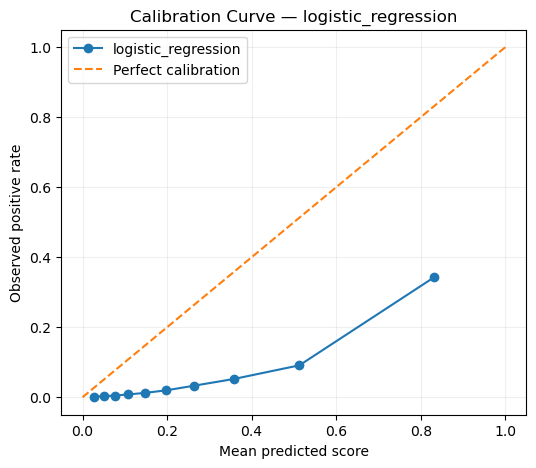

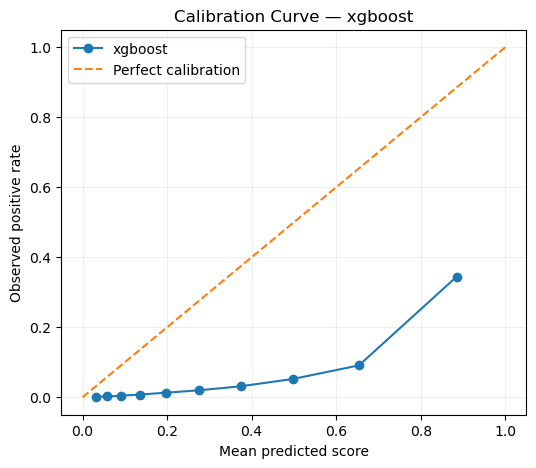

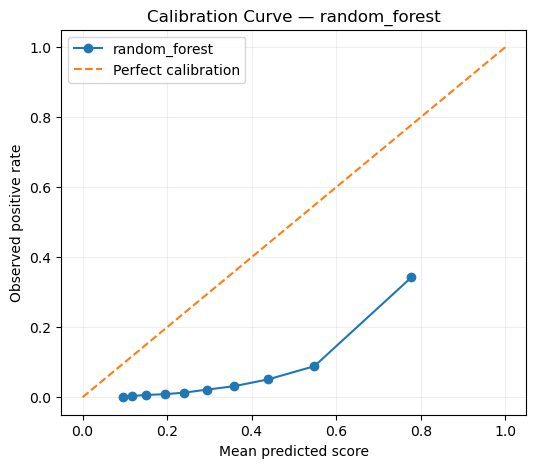

,model,mean_predicted_score,observed_positive_rate
0,logistic_regression,0.0266,0.0014
1,logistic_regression,0.0500,0.0031
2,logistic_regression,0.0761,0.0048
3,logistic_regression,0.1081,0.0079
4,logistic_regression,0.1474,0.0124
5,logistic_regression,0.1971,0.0195
6,logistic_regression,0.2628,0.0327
7,logistic_regression,0.3583,0.0522
8,logistic_regression,0.5129,0.0911
9,logistic_regression,0.8319,0.3429


In [23]:
import matplotlib.pyplot as plt

calibration_rows = []

for model_name, scores in oof_scores.items():
    prob_true, prob_pred = calibration_curve(
        y,
        scores,
        n_bins=10,
        strategy="quantile"
    )

    table = pd.DataFrame({
        "model": model_name,
        "mean_predicted_score": prob_pred,
        "observed_positive_rate": prob_true
    })

    calibration_rows.append(table)

    plt.figure(figsize=(6, 5))
    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=model_name
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )
    plt.xlabel("Mean predicted score")
    plt.ylabel("Observed positive rate")
    plt.title(f"Calibration Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

calibration_df = pd.concat(
    calibration_rows,
    ignore_index=True
)

display(calibration_df.round(4))

## 25. Candidate comparison

In [24]:
candidate_rows = []

for _, row in selected_thresholds.iterrows():
    model_name = row["model"]

    rank_row = ranking_df[
        ranking_df["model"] == model_name
    ].iloc[0]

    saved = load_saved_tuning_result(model_name)

    candidate_rows.append({
        "model": model_name,
        "selected_threshold": row["threshold"],
        "recall": row["recall"],
        "precision": row["precision"],
        "f1": row["f1"],
        "fn": int(row["fn"]),
        "fp": int(row["fp"]),
        "pr_auc": rank_row["pr_auc"],
        "roc_auc": rank_row["roc_auc"],
        "brier_score": rank_row["brier_score"],
        "best_hyperparameters": saved["best_params"],
        "mlflow_tuning_run_id": saved["run_id"],
    })

candidate_comparison = pd.DataFrame(
    candidate_rows
).sort_values(
    ["recall", "pr_auc", "brier_score"],
    ascending=[False, False, True]
)

display(
    candidate_comparison[
        [
            "model",
            "selected_threshold",
            "recall",
            "precision",
            "f1",
            "pr_auc",
            "roc_auc",
            "brier_score",
            "fn",
            "fp",
        ]
    ].round(4)
)

,model,selected_threshold,recall,precision,f1,pr_auc,roc_auc,brier_score,fn,fp
0,logistic_regression,0.36,0.8137,0.1874,0.3047,0.4016,0.8847,0.1050,3742,70848
2,random_forest,0.44,0.8035,0.1844,0.2999,0.3944,0.8799,0.1281,3946,71396
1,xgboost,0.52,0.8027,0.1958,0.3148,0.4133,0.8868,0.1476,3963,66229


## 26. Nominate Stage 6 leading candidate

In [25]:
eligible = candidate_comparison[
    candidate_comparison["recall"] >= RECALL_TARGET
].copy()

if len(eligible):
    nomination_table = eligible.sort_values(
        ["pr_auc", "brier_score", "f1"],
        ascending=[False, True, False]
    )
else:
    nomination_table = candidate_comparison.sort_values(
        ["recall", "pr_auc", "brier_score"],
        ascending=[False, False, True]
    )

leading_candidate = nomination_table.iloc[0]

print("Stage 6 leading candidate:")
print("Model              :", leading_candidate["model"])
print(
    "Selected threshold :",
    round(float(leading_candidate["selected_threshold"]), 4)
)
print(
    "Recall             :",
    round(float(leading_candidate["recall"]), 4)
)
print(
    "Precision          :",
    round(float(leading_candidate["precision"]), 4)
)
print(
    "PR-AUC             :",
    round(float(leading_candidate["pr_auc"]), 4)
)
print(
    "Brier Score        :",
    round(float(leading_candidate["brier_score"]), 4)
)

print(
    "\nThis is a Stage 6 nomination only. "
    "Fairness, SHAP and governance checks are still required."
)

Stage 6 leading candidate:
Model              : xgboost
Selected threshold : 0.52
Recall             : 0.8027
Precision          : 0.1958
PR-AUC             : 0.4133
Brier Score        : 0.1476

This is a Stage 6 nomination only. Fairness, SHAP and governance checks are still required.


## 27. Save Stage 6 final evidence

In [26]:
candidate_file = CONFIG_DIR / "stage6_candidate_comparison.csv"
threshold_file = CONFIG_DIR / "stage6_selected_thresholds.csv"
calibration_file = CONFIG_DIR / "stage6_calibration_table.csv"
nomination_file = CONFIG_DIR / "stage6_candidate_nomination.json"

candidate_comparison.to_csv(
    candidate_file,
    index=False
)

selected_thresholds.to_csv(
    threshold_file,
    index=False
)

calibration_df.to_csv(
    calibration_file,
    index=False
)

nomination = {
    "leading_candidate":
        str(leading_candidate["model"]),
    "feature_set":
        "full",
    "selected_threshold":
        float(leading_candidate["selected_threshold"]),
    "recall":
        float(leading_candidate["recall"]),
    "precision":
        float(leading_candidate["precision"]),
    "f1":
        float(leading_candidate["f1"]),
    "pr_auc":
        float(leading_candidate["pr_auc"]),
    "roc_auc":
        float(leading_candidate["roc_auc"]),
    "brier_score":
        float(leading_candidate["brier_score"]),
    "status":
        (
            "Stage 6 nomination only - pending fairness, SHAP, "
            "error analysis and governance review"
        )
}

nomination_file.write_text(
    json.dumps(nomination, indent=2),
    encoding="utf-8"
)

print("Saved:")
print(" -", candidate_file.relative_to(PROJECT_ROOT))
print(" -", threshold_file.relative_to(PROJECT_ROOT))
print(" -", calibration_file.relative_to(PROJECT_ROOT))
print(" -", nomination_file.relative_to(PROJECT_ROOT))

Saved:
 - config/stage6_candidate_comparison.csv
 - config/stage6_selected_thresholds.csv
 - config/stage6_calibration_table.csv
 - config/stage6_candidate_nomination.json


# Recovery instructions

If SageMaker disconnects or the kernel restarts:

1. Reopen this notebook.
2. Run Sections **1–10**.
3. Run **Section 11 — Recovery cell**.
4. It will show which models were already saved.
5. Run only the model section that says `NOT FOUND`.
6. OOF sections also reuse saved files if they already exist.

Example:

```text
RECOVERED | logistic_regression  | PR-AUC=...
RECOVERED | xgboost              | PR-AUC=...
NOT FOUND | random_forest
```

Then run only Section 14.

The locked holdout remains untouched throughout Stage 6.